In [17]:
import xarray as xr
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import os
os.environ['USE_PYGEOS'] = '0'
import geopandas
import regionmask
from eofs.xarray import Eof
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import glob
import seaborn as sns
sns.set_style("white")
import cartopy.feature as cfeature
import scipy.stats as stats


random_seed=123

In [18]:
def get_region(X,region):

    abbrevs= X.region.abbrevs
    I=np.nonzero(np.in1d(abbrevs,region))[0]
    data=X.sel(region=X.region.values[I])
    #data["region"]=region
    return data
def standardize(X):
    pi=X.sel(time=slice(1850,1899))
    mu=pi.mean(dim="time")
    sigma=pi.std(dim="time")
    return (X-mu)/sigma


# Reading in the drought atlas data
GEDA from Cook et al 2024

In [19]:
fname_geda = "../DATA/geda_trim.nc"
geda=xr.open_dataset(fname_geda)
geda=geda.scPDSI
#Ocean mask = 9.e36
geda=geda.where(geda<1.e20)
geda=geda.rename({"yr":"time"})

# AR6 regions
Average GEDA over AR6 land regions and eliminate regions where coverage is verysparse (GIC, NEAF, SAH)

In [20]:
geda_regions=np.array(['NEU', 'WCE', 'EEU', 'MED', 'RAR', 'WSB',
       'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS','SEA'])

In [21]:
mask=regionmask.defined_regions.ar6.land.mask_3D(geda)
weights = np.cos(np.deg2rad(geda.lat))
drought_regional = geda.weighted(mask * weights).mean(dim=("lat", "lon"))
drought_regional=drought_regional.dropna(dim="region")
#drought_regional=get_region(drought_regional,geda_regions)

In [22]:
def plot_full(year):
    fig=plt.figure(figsize=(10,5))
    ax=regionmask.defined_regions.ar6.land.plot(label="abbrev")
    kids=ax.get_children()
    kid=kids[20]
    for kid in kids:
        if type(kid) == mpl.text.Text:
            if not (kid.get_text() in drought_regional.region.abbrevs.values):
                kid.set_visible(False)
    geda.sel(time=year).plot(cmap=cm.BrBG)
    #ax.add_feature(cfeature.OCEAN)
    ax.set_ylim(-11,83)
    ax.set_xlim(-12,180)
    tmp=fig.suptitle("PDSI: year "+str(year)+"CE")
    plt.tight_layout()
#plt.savefig("../Writeup/FIGS/GEDA.png")

In [23]:
# standardize and scale
def prep_drought_atlas_data(regions=geda_regions,pi_period=(1000,1849),recent_period=(1900,2020)):
    data=get_region(drought_regional,regions)
    preindustrial=data.sel(time=slice(pi_period[0],pi_period[1]))
    #standardize using preindustrial mean and sigma
    mu=preindustrial.mean(dim="time")
    sigma=preindustrial.std(dim="time")
    preindustrial_scaled=(preindustrial-mu)/sigma
    
    #standardize using mu and sigma from preindustrial
    recent=data.sel(time=slice(recent_period[0],recent_period[1]))
    recent_scaled=(recent-mu)/sigma
    preindustrial_scaled["region"]=regions
    recent_scaled["region"]=regions
    return preindustrial_scaled,recent_scaled
        

In [24]:
def match_region_abbrev_to_number(regionabbrev):
    return regionmask.defined_regions.ar6.all.abbrevs.index(regionabbrev)
    


# Lag properties by region

In [25]:
def plot_GEDA(X,cmap=cm.BrBG,**kwargs):
    
    lon=np.arange(-11, 180)
    #lat=np.arange(-20,90)
    lat = np.arange(-10, 80)
    #lon=geda.lon
    #lat=geda.lat
    
    lon_edges=lon
    lat_edges=lat
    
    # for the plotting
    #lon_edges = np.arange(-180, 181)
    #lat_edges = np.arange(-90, 91)
    mask = regionmask.defined_regions.ar6.land.mask(lon, lat).values
    
    mask_ma = np.ma.masked_invalid(mask)
    my_mask=np.zeros_like(mask_ma)
    the_lag=-2
    
    for region in X.region:
        regnum=match_region_abbrev_to_number(region)
        my_mask[mask_ma==regnum]=float(X.sel(region=region))
    
    proj = ccrs.PlateCarree()
    ax = plt.subplot(111, projection=proj)
    
    #mask_ma = np.ma.masked_invalid(mask)
    
    
    my_mask=np.ma.masked_where(my_mask==0,my_mask)
    h = ax.pcolormesh(lon_edges, lat_edges, my_mask, transform=ccrs.PlateCarree(), cmap=cmap,**kwargs)
    cbar=plt.colorbar(h)
    
    ax.coastlines()
    return ax,cbar


In [26]:
def pretty_plot_GEDA(X,**kwargs):
    plt.figure(figsize=(10,5))
    axes=regionmask.defined_regions.ar6.land.plot(label="abbrev")
    kids=axes.get_children()
    kid=kids[20]
    for kid in kids:
        if type(kid) == mpl.text.Text:
            if not (kid.get_text() in X.region):
                kid.set_visible(False)
    ax,cbar=plot_GEDA(X,**kwargs)
    #ax=plt.gca()
    ax.add_feature(cfeature.OCEAN)
    ax.set_ylim(-11,83)
    ax.set_xlim(-12,180)
    return ax,cbar

In [27]:
def plot_lag(trace,lag=-1,**kwargs):
  
    # Lag-1 coefficients
    plt.figure(figsize=(10,5))
    axes=regionmask.defined_regions.ar6.land.plot(label="abbrev")
    kids=axes.get_children()
    kid=kids[20]
    for kid in kids:
        if type(kid) == mpl.text.Text:
            if not (kid.get_text() in trace.posterior.region):
                kid.set_visible(False)
    if "vmin" in kwargs.keys():
        vmin=kwargs["vmin"]
    else:
        vmin=0
    if "vmax" in kwargs.keys():
        vmax=kwargs["vmax"]
    else:
        vmax=0.5
    if "cmap" in kwargs.keys():
        cmap=kwargs["cmap"]
    else:
        cmap=cm.Reds
    ax,cbar=plot_GEDA(getattr(trace.posterior,"lag_coef").sel(lags=lag).mean(dim=("chain","draw")),cmap=cmap,vmin=vmin,vmax=vmax)
    #ax=plt.gca()
    ax.add_feature(cfeature.OCEAN)
    ax.set_ylim(-11,83)
    ax.set_xlim(-12,180)
    cbar.set_label("Lag-1 coefficient")

#plt.savefig("../Writeup/FIGS/Lag1Coefficient.png")

# Covariance Matrix
Plotting the covariance matrix and comparing it to EOFs

In [28]:
def plot_covariance(trace):
    regns=trace.posterior.region.values
    # Represent the correlation matrix
    plt.figure(figsize=(10,10))
    mycov=getattr(trace.posterior,"cov").mean(dim=("chain","draw")).values
    corr_mat = np.tril(mycov, k=-1)
    corr_mat = np.ma.masked_where(corr_mat==0,corr_mat)
    plt.imshow(corr_mat,cmap=cm.coolwarm,vmin=-.5,vmax=.5)
    plt.colorbar(label="Covariance",location="left")
    tmp=plt.xticks(np.arange(len(regns)),regns,rotation=90)
    tmp=plt.yticks(np.arange(len(regns)),regns,rotation=0)
    plt.gca().set_frame_on(False)
    plt.tight_layout()
#plot_covariance(both_trace)
#plt.savefig("../Writeup/FIGS/Covariance.png")

In [29]:
def plot_regional_covariance(trace,region="NEU"):
    regns=trace.posterior.region.values
    plt.figure(figsize=(5,10))
    neu_cov_posteriors=getattr(trace.posterior,"cov").sel(region=region).stack(samples=("chain","draw"))
    
    postmeans=neu_cov_posteriors.mean(dim="samples")
    #mn=np.min(postmeans)
    #mx=np.max(postmeans)
    mn=-0.4
    mx=0.4
    postmeans_scaled=(postmeans-mn)/(mx-mn)
    
    i=1
    
    
    nreg=len(coords["region"])
    for reg in coords["region"]:
        plt.subplot(5,3,i)
        sns.histplot(neu_cov_posteriors.sel(cross_region=reg),color=cm.coolwarm(postmeans_scaled.values[i-1]))
        plt.title(reg)
        plt.ylabel("")
        plt.yticks([])
        
    
        i+=1
    plt.tight_layout()
#plot_regional_covariance(both_trace)
#plt.savefig("../Writeup/FIGS/Covariance_Uncertainty.png")

# Visualizing the covariance matrix

In [30]:
def plot_leading_eig(trace):
    mycov==getattr(trace.posterior,"cov").mean(dim=("chain","draw"))
    from numpy import linalg as LA
    eigenvalues,eigenvectors=LA.eig(mycov)
    eof1=eigenvectors[:,0]
    ax,cbar=pretty_plot_GEDA(xr.DataArray(data=-eof1,dims=["region"],coords={"region":np.array(coords["region"])}),cmap=cm.BrBG,\
                    vmin=-.5,vmax=.5)
    cbar.set_label("Eigenvector Value")
#plt.savefig("../Writeup/FIGS/Leading_Eigenvector.png")

# Comparision with EOF1
It resembles the leading EOF in many places, but note that the leading EOF neither incorporates uncertainty nor takes into account the autoregressive noise.

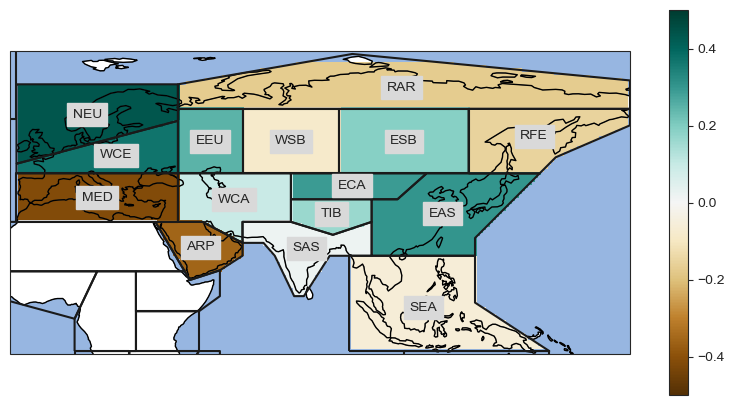

In [88]:

preindustrial,recent= prep_drought_atlas_data([ 'NEU', 'WCE', 'EEU', 'MED',  'RAR', 'WSB',
       'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS',"SEA",],recent_period=(1850,2020))

solver=Eof(preindustrial)
pretty_plot_GEDA(solver.eofs().sel(mode=0),cmap=cm.BrBG,\
                vmin=-.5,vmax=.5)
#cbar.set_label("EOF loading")
plt.savefig("../Writeup/FIGS/EOF1.png",dpi=1000)

In [32]:
#maximum number of lags considered
#User can change this, but for now we set to 3
#Has to be pre-set so every model uses the same shape data (nt-maxlags)
maxlags=3


# AR(p) models
Assume data depends on $n_{lag}$ previous years
$$D \sim N\left(\mathbf{F}(t) +  \sum_{j=1}^{n_{lag}} \ell_j \mathbf{D}(t-j)  , \Sigma\right)$$

In [33]:
# assume zero forcing in the preindustrial, forced term in the recent




#preindustrial,recent=prep_data(["WCE","EEU","MED","NEU"])

class ARF():
    def __init__(self,lags,maxlags=3,recent_period=(1850,2020),pi_period=(1000,1849)):
        self.lags=lags
        
        
        preindustrial,recent= prep_drought_atlas_data([ 'NEU', 'WCE', 'EEU', 'MED',  'RAR', 'WSB',
                                                       'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS',"SEA"],\
                                                      pi_period=pi_period,recent_period=recent_period)
        self.coords={"lags": reversed(range(-lags, 0)),
            "region": tuple(preindustrial.region.values),
            "cross_region":tuple(preindustrial.region.values),
            "time_pi": preindustrial.time[maxlags:],
            "time_recent": recent.time[maxlags:]
        }

        self.data={}
        self.data["preindustrial"]=preindustrial
        self.data["recent"]=recent

        with pm.Model(coords=self.coords) as self.model:
            # AR(lags) model for temporal variability
            lag_coefs = pm.Normal("lag_coef", mu=0, sigma=1, dims=("lags", "region"))
            # Unknown forced response over recent period, defined as variability not compatible with lag-2 multivariate normal
            F = pm.Normal("F",mu=0,sigma=1,shape=(len(self.coords["time_recent"]),len(self.coords["region"])),\
                          dims=("time_recent","region"))
            #Assume preindustrial variability is unforced
            F_pi=0
           
            # Compute autoregressive expectation for each region
        
            ar_pi={}
            ar_recent={}
            
            for regn in self.coords["region"]:
                j=self.coords["region"].index(regn)
                ar_pi[regn] = pm.math.sum([lag_coefs[i, j] * preindustrial.values[maxlags-(i+1): -(i+1),j]
                    for i in range(lags)
                ], axis=0)  
                ar_recent[regn] = pm.math.sum([lag_coefs[i, j] * recent.values[maxlags-(i+1): -(i+1),j]
                    for i in range(lags)
                ], axis=0) 
                
        
               
        
            # Stack autoregressive terms and add intercepts
            
            mean_pi = F_pi + pm.math.stack([ar_pi[regn] for regn in self.coords["region"]], axis=-1)
            mean_recent = F + pm.math.stack([ar_recent[regn] for regn in self.coords["region"]], axis=-1)
            
        
          
        
           
           
            # For modelling simplicity, we ignore the first observations, where we could
            # not observe the effects of all the lagged coefficients
            
             #now take into account spatial covariance
            sigmaDist = pm.Exponential.dist(1.0)
            chol,_,_ = pm.LKJCholeskyCov('L', eta=4, n=len(self.coords["region"]),\
                                                   sd_dist=sigmaDist,compute_corr=True)
            #chol = pm.expand_packed_triangular(len(coords["region"]), packed_chol, lower=True)
            cov = pm.Deterministic('cov', chol.dot(chol.T),dims=("region","cross_region"))
            obs = pm.MvNormal("obs_pi", mu=mean_pi, chol=chol, observed=self.data["preindustrial"][maxlags:], dims=("time_pi", "region"))
            obs_recent = pm.MvNormal("obs_recent", mu=mean_recent, chol=chol, observed=self.data["recent"][maxlags:], dims=("time_recent", "region"))
            #obs_recent = pm.MvNormal("obs_recent",mu=mean_recent,chol=chol,observed=recent[lags:],dims=("time_recent","region"))
    def sample(self):
        if hasattr(self,"trace"):
            pass
        else:
            with self.model:
                self.trace=pm.sample(return_inferencedata=True)
                ll=pm.compute_log_likelihood(self.trace)

# Running the models
Calculate posteriors for AR(3), AR(2), AR(1) models 

In [34]:
maxlags=3
AR3=ARF(3,maxlags)
AR3.sample()

AR2=ARF(2,maxlags)
AR2.sample()

AR1=ARF(1,maxlags)
AR1.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lag_coef, F, L]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 98 seconds.


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lag_coef, F, L]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 96 seconds.


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lag_coef, F, L]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 87 seconds.


# Remove temporal dependence: just parameterize by spatial covariance

$$D \sim N(0,\Sigma)$$

In [35]:
# assume zero forcing in the preindustrial, zero AR, but spatial covariance structure
recent_period=(1850,2020)
pi_period=(1000,1849)

preindustrial,recent= prep_drought_atlas_data([ 'NEU', 'WCE', 'EEU', 'MED',  'RAR', 'WSB',
                                                       'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS',"SEA"],\
                                                      pi_period=pi_period,recent_period=recent_period)

coords={
    "region": tuple(preindustrial.region.abbrevs.values),
    "cross_region":tuple(preindustrial.region.abbrevs.values),
    "time_pi": preindustrial.time[maxlags:],
    "time_recent": recent.time[maxlags:]
}



with pm.Model(coords=coords) as justspace:
    
    # Unknown forced response over recent period, defined as variability not compatible with lag-2 multivariate normal
    F = pm.Normal("F",mu=0,sigma=1,shape=(len(coords["time_recent"]),len(coords["region"])),\
                  dims=("time_recent","region"))
    # Unknown forced response over preindustrial period, same prior
    # F_pi = pm.Normal("F_pi",mu=0,sigma=1,shape=(len(coords["time_pi"]),len(coords["region"])),\
    #                dims=("time_pi","region"))
    F_pi=0
    #T=T_nonstandard[lags:]
    #beta = pm.Normal("beta",mu=0,sigma=1,dims=("time_recent"))
    

  

   
   
    # For modelling simplicity, we ignore the first observations, where we could
    # not observe the effects of all the lagged coefficients
    
     #now take into account spatial covariance
    sigmaDist = pm.Exponential.dist(1.0)
    chol,_,_ = pm.LKJCholeskyCov('L', eta=4, n=len(coords["region"]),\
                                           sd_dist=sigmaDist,compute_corr=True)
    #chol = pm.expand_packed_triangular(len(coords["region"]), packed_chol, lower=True)
    cov = pm.Deterministic('cov', chol.dot(chol.T),dims=("region","cross_region"))
    obs = pm.MvNormal("obs_pi", mu=0, chol=chol, observed=preindustrial[maxlags:], dims=("time_pi", "region"))
    obs_recent = pm.MvNormal("obs_recent", mu=0, chol=chol, observed=recent[maxlags:], dims=("time_recent", "region"))
    #obs_recent = pm.MvNormal("obs_recent",mu=mean_recent,chol=chol,observed=recent[lags:],dims=("time_recent","region"))
    justspace_trace=pm.sample(return_inferencedata=True)
    ll=pm.compute_log_likelihood(justspace_trace)
    

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [F, L]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 68 seconds.


In [36]:
with pm.Model(coords=coords) as whitenoise:
    sigma = pm.HalfNormal("white_noise_sigma",10,shape=len(coords["region"]))
    cov=pt.eye(len(coords["region"]))*sigma
    obs = pm.MvNormal("obs_pi", mu=0, cov=cov, observed=preindustrial[maxlags:], dims=("time_pi", "region"))
    obs_recent = pm.MvNormal("obs_recent", mu=0, cov=cov, observed=recent[maxlags:], dims=("time_recent", "region"))
    #obs_recent = pm.MvNormal("obs_recent",mu=mean_recent,chol=chol,observed=recent[lags:],dims=("time_recent","region"))
    whitenoise_trace=pm.sample()
    ll=pm.compute_log_likelihood(whitenoise_trace)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [white_noise_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


We have assumed that the PDSI in any given region co-varies with the PDSI in other regions, and that PDSI in any given year depends on its value in the two preceeding years. In other words, we have used a particular statistical model to interpret preindustrial variability as represented in the GEDA. However, other models may better capture the spatiotemporal structure. Perhaps the PDSI in some regions depends on PDSI in the three prior years, or only on the preceding year, or is independent of its previous value. Perhaps regional PDSI is independent of that in other regions. We must therefore assess how well the model we use, which we call , is able to describe the spatiotemporal structure in the GEDA between 1000 and 1850.

A common method of Bayesian model comparison is leave-one-out cross validation (LOO-CV), in which we exclude data for one year, attempt to predict it with the model, and compare the model-predicted data to the left-out "real" data. We then repeat this for all years in the preindustrial GEDA. The sum of the log-likelihood over all excluded data points is a measure of the model fit: the observations will be more likely in a "better" model. We test the model  against three other models:  and , with 1 and 3 lags, respectively,  in which the PDSI is independent of PDSI in the year(s) before, and , in which PDSI in each region is independent of PDSI in all other regions and does not depend on PDSI in prior years.

The white noise model  has the fewest parameters, while the AR(3) model is able to capture the most structure. In statistical modeling, we balance two competing imperatives. On one hand, we want to avoid over-fitting with too many parameters. On the other, we want a model that explains the data well. This means adding parameters to a model is ``worth it" only if those parameters have additional explanatory power.

The LOO-CV analysis (Table XX) shows that  is the model that best describes the structure of pre-industrial variability. The additional parameters in do not increase the model's explanatory power, and it is down-weighted compared to the model we use. Conversely, although  has the fewest parameters, it is by far the worst performing model because there is real structure in the pre-industrial GEDA that cannot be captured by white noise.

In [37]:
# Where is lag2 likely nonzero?
AR2.trace.posterior.region[np.where(np.sign(az.hdi(AR2.trace.posterior.lag_coef.sel(lags=-2),hdi_prob=.99).lag_coef.sel(hdi="lower"))\
         == np.sign(az.hdi(AR2.trace.posterior.lag_coef.sel(lags=-2),hdi_prob=.99).lag_coef.sel(hdi="higher")))]

<xarray.DataArray 'region' (region: 4)> Size: 48B
array(['WSB', 'EAS', 'ARP', 'SEA'], dtype='<U3')
Coordinates:
  * region   (region) <U3 48B 'WSB' 'EAS' 'ARP' 'SEA'

In [38]:
df_compare_pi=az.compare({"AR3":AR3.trace,\
            "AR2":AR2.trace,\
            "AR1":AR1.trace,\
           "White noise":whitenoise_trace,\
           "Spatial covariance only":justspace_trace},\
           var_name="obs_pi")

/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'log' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (


In [39]:
df_compare_pi

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
AR2,0,-15762.265414,149.008368,0.000000,0.583247,90.808391,0.000000,False,log
AR3,1,-15766.470735,163.188943,4.205321,0.276298,90.820574,4.830645,False,log
AR1,2,-15798.454986,135.190485,36.189572,0.089896,91.580946,9.897162,False,log
Spatial covariance only,3,-16697.417070,93.917119,935.151656,0.050558,82.617968,46.516386,False,log
White noise,4,-18046.800178,11.948973,2284.534764,0.000000,93.906382,67.814590,False,log


In [1]:
#print(df_compare_pi[["rank","elpd_diff","dse"]].to_latex())

# Fingerprint model
Assume a global temperature dependent fingerprint F.  

/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, 

Text(0.5, 1.0, 'Global Temperature Relative to 1850-1900 average')

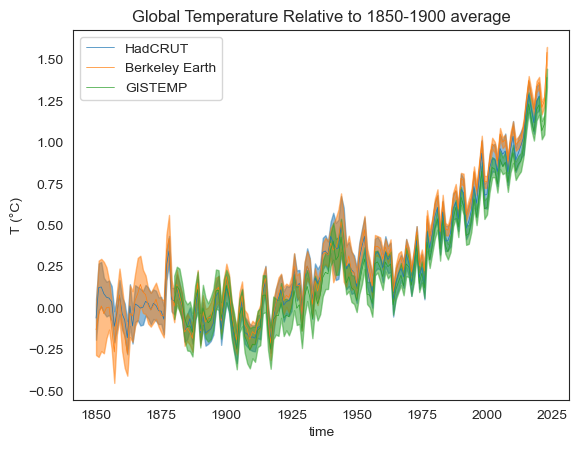

In [41]:

preindustrial,recent= prep_drought_atlas_data([ 'NEU', 'WCE', 'EEU', 'MED',  'RAR', 'WSB',
       'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS',"SEA",],recent_period=(1850,2020))

hadunc=xr.open_dataset("../DATA/OBS/HadCRUT.5.0.2.0.analysis.ensemble_series.global.annual.nc")
hadcrut_ensemble=hadunc.sel(time=slice("1850-1-1","2020-12-31")).tas
hadcrut_ensemble["time"]=recent.time
baseline=hadcrut_ensemble.sel(time=slice(1850,1900)).mean(dim="time")
hadcrut_ensemble=hadcrut_ensemble-baseline

hadcrut_ensemble=hadcrut_ensemble.expand_dims({"dataset":["HadCRUT"]})

# Read in Berkeley Earth
#uncertainties are the 95% confidence interval = 2 sigma
#I HATE PANDAS, there has to be an easier way to do this
bearth=pd.read_csv("https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",\
                  comment="%",header=0,sep="     ",engine="python")
first=[1850, -0.450,0.158,np.nan,np.nan,  -0.430 , 0.145,np.nan,np.nan]

titles=["Year", "Annual Anomaly", "Annual Unc.", "Five-year Anomaly", "Five-year Unc.",\
        "Annual Anomaly (below sea ice)", "Annual Unc. (below sea ice)", \
        "Five-year Anomaly (below sea ice)", "Five-year Unc. (below sea ice)"]

D={}
for i in range(len(titles)):
   
    D[titles[i]]=np.append(first[i],bearth[bearth.columns[i]].values)

bearth_data=pd.DataFrame(D)
d = {
    "coords": {
        "time": {"dims": "time", "data": D["Year"], "attrs": {"units": "years"}}
    },
    "attrs": {"title": "air temperature"},
    "dims": "time",
    "data_vars": {
        "tas": {"dims": "time", "data": D["Annual Anomaly"]},
        "unc": {"dims": "time", "data": D["Annual Unc."]},
    },
}
berkeleyearth = xr.Dataset.from_dict(d)
# create an artificial ensemble
mu_be=berkeleyearth.tas.values
sigma_be=berkeleyearth.unc.values/2.
berkeley_earth_ensemble=np.zeros((200,len(mu_be)))
for i in range(len(mu_be)):
    berkeley_earth_ensemble[:,i]=np.random.normal(mu_be[i],sigma_be[i],200)
berkeley_earth_ensemble=xr.DataArray(data=berkeley_earth_ensemble[np.newaxis,:,:],dims=("dataset","realization","time"),\
coords={"dataset":["Berkeley Earth"],"realization":hadcrut_ensemble.realization,"time":berkeleyearth.time})


# read in GISTEMP
gistemp_data=pd.read_csv("https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv",header=1)
gistemp_data["J-D"]
gistemp=xr.DataArray(data=gistemp_data["J-D"].values[:-1].astype(np.float32),\
                     dims=("time"),\
                     coords={"time":gistemp_data["Year"].values[:-1]}).rename("tas")

# giss uncertainty: this is two sigma
gissunc=pd.read_csv("https://data.giss.nasa.gov/gistemp/uncertainty/v1.2.1/totalCI_ERA.csv")
sigma_gis=gissunc["ci95"].values/2.
# pad with last value to extend it to 2023
nextra=len(gistemp.time)-len(sigma_gis)
sigma_gis=np.append(sigma_gis,np.tile(sigma_gis[-1],nextra))
mu_gis=gistemp.values
gistemp_ensemble=np.zeros((200,len(mu_gis)))
for i in range(len(mu_gis)):
    gistemp_ensemble[:,i]=np.random.normal(mu_gis[i],sigma_gis[i],200)
gistemp_ensemble=xr.DataArray(data=gistemp_ensemble[np.newaxis,:,:],dims=("dataset","realization","time"),\
coords={"dataset":["GISTEMP"],"realization":hadcrut_ensemble.realization,"time":gistemp.time})


#Make a merged dataset of all temperature anomalies and their uncertainties
T_anomalies=xr.concat([hadcrut_ensemble,berkeley_earth_ensemble,gistemp_ensemble],dim="dataset")
T_anomalies=T_anomalies -T_anomalies.sel(time=slice(1850,1900)).mean(dim="time")
tmp=[T_anomalies.mean(dim="realization").isel(dataset=i).plot(lw=.5,label=T_anomalies.dataset.values[i]) for i in range(3)]
tmp=[az.plot_hdi(T_anomalies.time.values,T_anomalies.isel(dataset=i),smooth=False,color=cm.tab10(i),hdi_prob=.95) for i in range(3)]
T_anomalies=T_anomalies.sel(time=slice(1850,2020))
plt.legend()
plt.ylabel("T (°C)")
plt.title("Global Temperature Relative to 1850-1900 average")

In [42]:
# assume a constant fingerprint that scales with temperature

lags = 2

coords={
    "lags": reversed(range(-lags, 0)),
    "region": tuple(preindustrial.region.abbrevs.values),
    "cross_region":tuple(preindustrial.region.abbrevs.values),
    "time_pi": preindustrial.time[maxlags:],
    "time_recent":recent.time[maxlags:]
}

with pm.Model(coords=coords) as global_T_model:
    #Learn the uncertain T
    T=pm.Normal("T",0,1,dims=("time_recent"))
    tau=pm.HalfNormal("τ",1)
    Tobserved={}
    theta={}
    for dataset in ["HadCRUT","Berkeley Earth","GISTEMP"]:
        data=T_anomalies.sel(dataset=dataset).values[:,maxlags:]
        theta[dataset]=pm.Normal("θ_"+dataset,T,tau,dims=("time_recent"))
        std=np.std(data,axis=0)
        if dataset == "GISTEMP":
            #Pad the standard deviation: missing data here
            std=np.where(~np.isnan(std),std,1)
        Tobserved[dataset]=pm.Normal(dataset,theta[dataset],sigma=std,observed=data)

    
    # Priors for the intercept, lagged coefficient, and noise terms
    intercept = 0 # during the pre-industrial period
    lag_coefs = pm.Normal("ℓ", mu=0, sigma=1, dims=("lags", "region"))
    # prior on fingerprint of regional PDSI response
    fingerprint=pm.Normal("β",mu=0,sigma=1,dims=("region"))
    
   

    # Compute autoregressive expectation for each region in preindustrial and recent.
    #Assume same lag coefs for both

    ar_pi={}
    ar_recent={}
    
    for regn in coords["region"]:
        j=coords["region"].index(regn)
        ar_pi[regn] = pm.math.sum([lag_coefs[i, j] * preindustrial.values[maxlags-(i+1): -(i+1),j]
            for i in range(lags)
        ], axis=0)  

        ar_recent[regn] = pm.math.sum([lag_coefs[i, j] * recent.values[maxlags-(i+1): -(i+1),j]
            for i in range(lags)
        ], axis=0)  
        
        

    # Stack autoregressive terms and add intercepts
    
    mean_pi = intercept + pm.math.stack([ar_pi[regn] for regn in coords["region"]], axis=-1)

  
    forced_response = pm.Deterministic("forced_response",\
                                       pm.math.stack([T*fingerprint[i] for i in range(len(coords["region"]))],\
                                                     axis=-1),dims=("time_recent", "region"))

    mean_recent = forced_response + pm.math.stack([ar_recent[regn] for regn in coords["region"]], axis=-1)

   
   
     #now take into account spatial covariance
    sigmaDist = pm.Exponential.dist(1.0)
    chol,_,_ = pm.LKJCholeskyCov('L', eta=4, n=len(coords["region"]),\
                                           sd_dist=sigmaDist,compute_corr=True)
    #chol = pm.expand_packed_triangular(len(coords["region"]), packed_chol, lower=True)
    cov = pm.Deterministic('Σ', chol.dot(chol.T),dims=("region","cross_region"))
    obs = pm.MvNormal("obs_pi", mu=mean_pi, chol=chol, observed=preindustrial[maxlags:], dims=("time_pi", "region"))
    obs_recent = pm.MvNormal("obs_recent",mu=mean_recent,chol=chol,observed=recent[maxlags:],dims=("time_recent","region"))
    global_T_trace=pm.sample()
    ll=pm.compute_log_likelihood(global_T_trace)

/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/pymc/model/core.py:1316: ImputationWarning: Data in GISTEMP contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [T, τ, θ_HadCRUT, θ_Berkeley Earth, θ_GISTEMP, GISTEMP_unobserved, ℓ, β, L]


/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 210 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [43]:
# assume zero forcing in the preindustrial, no forced term in the recent



#preindustrial,recent=prep_data(["WCE","EEU","MED","NEU"])

class ARnoF():
    def __init__(self,lags,maxlags=3,pi_period=(1000,1849),recent_period=(1880,2020)):
        self.lags=lags
        
        
        preindustrial,recent= prep_drought_atlas_data([ 'NEU', 'WCE', 'EEU', 'MED',  'RAR', 'WSB',
                                                       'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS',"SEA"],\
                                                      pi_period=pi_period,
                                                      recent_period=recent_period)
        self.coords={"lags": reversed(range(-lags, 0)),
            "region": tuple(preindustrial.region.abbrevs.values),
            "cross_region":tuple(preindustrial.region.abbrevs.values),
            "time_pi": preindustrial.time[maxlags:],
            "time_recent": recent.time[maxlags:]
        }

        self.data={}
        self.data["preindustrial"]=preindustrial
        self.data["recent"]=recent

        with pm.Model(coords=self.coords) as self.model:
            # AR(lags) model for temporal variability
            lag_coefs = pm.Normal("lag_coef", mu=0, sigma=1, dims=("lags", "region"))
            # No forcing over recent period
            F=0
            #Assume preindustrial variability is unforced
            F_pi=0
           
            # Compute autoregressive expectation for each region
        
            ar_pi={}
            ar_recent={}
            
            for regn in self.coords["region"]:
                j=self.coords["region"].index(regn)
                ar_pi[regn] = pm.math.sum([lag_coefs[i, j] * preindustrial.values[maxlags-(i+1): -(i+1),j]
                    for i in range(lags)
                ], axis=0)  
                ar_recent[regn] = pm.math.sum([lag_coefs[i, j] * recent.values[maxlags-(i+1): -(i+1),j]
                    for i in range(lags)
                ], axis=0) 
                
        
               
        
            # Stack autoregressive terms and add intercepts
            
            mean_pi = F_pi + pm.math.stack([ar_pi[regn] for regn in coords["region"]], axis=-1)
            mean_recent = F + pm.math.stack([ar_recent[regn] for regn in coords["region"]], axis=-1)
            
        
          
        
           
           
            # For modelling simplicity, we ignore the first observations, where we could
            # not observe the effects of all the lagged coefficients
            
             #now take into account spatial covariance
            sigmaDist = pm.Exponential.dist(1.0)
            chol,_,_ = pm.LKJCholeskyCov('L', eta=4, n=len(self.coords["region"]),\
                                                   sd_dist=sigmaDist,compute_corr=True)
            #chol = pm.expand_packed_triangular(len(coords["region"]), packed_chol, lower=True)
            cov = pm.Deterministic('cov', chol.dot(chol.T),dims=("region","cross_region"))
            obs = pm.MvNormal("obs_pi", mu=mean_pi, chol=chol, observed=self.data["preindustrial"][maxlags:], dims=("time_pi", "region"))
            obs_recent = pm.MvNormal("obs_recent", mu=mean_recent, chol=chol, observed=self.data["recent"][maxlags:], dims=("time_recent", "region"))
            #obs_recent = pm.MvNormal("obs_recent",mu=mean_recent,chol=chol,observed=recent[lags:],dims=("time_recent","region"))
    def sample(self):
        if hasattr(self,"trace"):
            pass
        else:
            with self.model:
                self.trace=pm.sample(return_inferencedata=True)
                ll=pm.compute_log_likelihood(self.trace)

In [44]:
AR2_noF=ARnoF(2,recent_period=(1850,2020))
AR2_noF.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lag_coef, L]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 49 seconds.


In [45]:
AR2_noF=ARnoF(2,recent_period=(1850,2020))
AR2_noF.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lag_coef, L]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 50 seconds.


In [46]:
#AR2.trace.log_likelihood.obs_recent
df_compare_rec=az.compare({"$M_{FT}":global_T_trace,"$M_{\Sigma2}":AR2_noF.trace},var_name="obs_recent",method="BB-pseudo-BMA")

/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'log' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (


In [2]:
#print(df_compare_rec[["rank","elpd_diff","dse"]].to_latex())

# How likely are recent observations given preindustrial noise?
What is the probability of observing PDSI data D in year t given D in years t-1 and t-2 as well as the spatial covariance?  Big drop in the likelihood in recent years.

(1000.0, 2025.0)

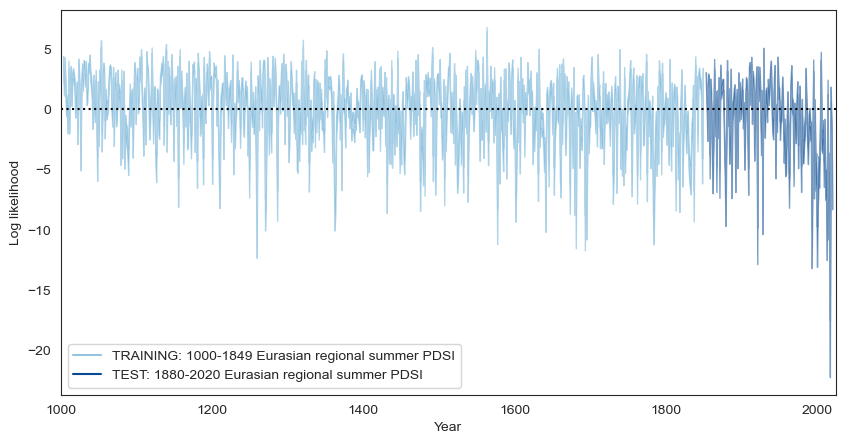

In [48]:
# the log likelihood decreases with time
fig=plt.figure(figsize=(10,5))
elpd=AR2_noF.trace.log_likelihood.obs_pi.mean(dim=("time_pi","chain","draw"))
#elpd=0
Tr=AR2_noF.trace.log_likelihood.obs_recent.time_recent.values
Tp=AR2_noF.trace.log_likelihood.obs_pi.time_pi.values
az.plot_hdi(Tr,-elpd+AR2_noF.trace.log_likelihood.obs_recent,smooth=False,color=cm.Blues(.9))
az.plot_hdi(Tp,-elpd+AR2_noF.trace.log_likelihood.obs_pi,smooth=False,color=cm.Blues(.5))

plt.axhline(0,ls=":",c="k")
tmps=[]
tmps+=[plt.axhline(0,color=cm.Blues(.4),label="TRAINING: 1000-1849 Eurasian regional summer PDSI")]
tmps+=[plt.axhline(0,color=cm.Blues(.9),label="TEST: 1880-2020 Eurasian regional summer PDSI")]

plt.legend(loc="lower left")
[x.set_visible(False) for x in tmps]
plt.xlabel("Year")
plt.ylabel("Log likelihood")

data=AR2_noF.trace.log_likelihood.obs_recent.mean(dim=("chain","draw"))
# plt.plot([year],data.sel(time_recent=year).values,marker="o",c="r")
#plt.xlim(1800,1900)
#plt.axvline(1258)
#az.plot_hdi(Tp,-elpd+trace.log_likelihood.obs_pi,smooth=False,color=cm.Reds(.5))

Tp[np.argsort(AR2_noF.trace.log_likelihood.obs_pi.mean(dim=("chain","draw")).values)[:25]]
#az.plot_hdi(Tr,AR2_beta.trace.log_likelihood.obs_recent,smooth=False,color=cm.Reds(.5))
plt.xlim(1000,2025)
#plt.savefig("../Writeup/FIGS/Likelihoods.png")

In [49]:
# Train it on different times in the past

AR2_noF_1000=ARnoF(2,pi_period=(1000,1199),recent_period=(1850,2020))
AR2_noF_1000.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lag_coef, L]


/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.


In [50]:
AR2_noF_1700=ARnoF(2,pi_period=(1650,1849),recent_period=(1850,2020))
AR2_noF_1700.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lag_coef, L]


/Users/kmarvel/anaconda3/envs/pymc_env/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.


In [52]:
# 1921 was severe drought over Europe van_der_Schrier_2021

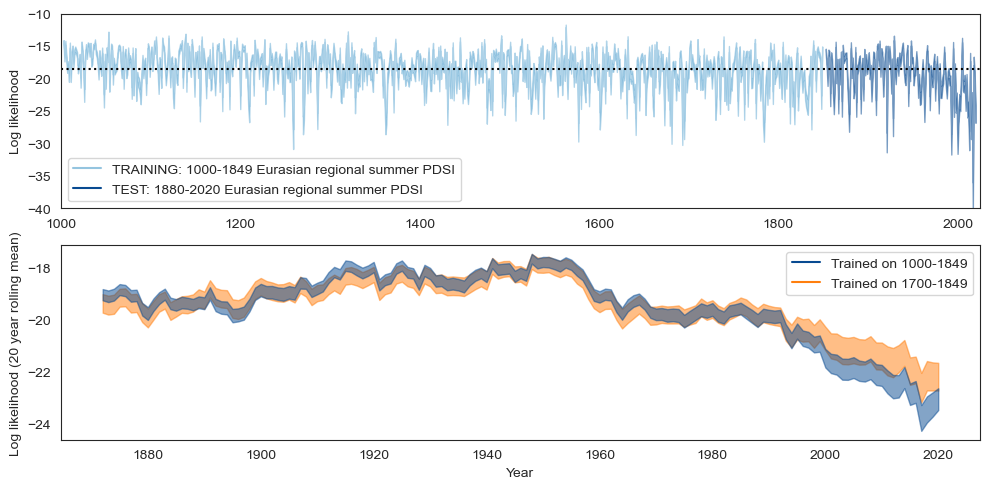

In [62]:
fig=plt.figure(figsize=(10,5))
plt.subplot(211)
elpd_line=AR2_noF.trace.log_likelihood.obs_pi.mean(dim=("time_pi","chain","draw"))
elpd=0
Tr=AR2_noF.trace.log_likelihood.obs_recent.time_recent.values
Tp=AR2_noF.trace.log_likelihood.obs_pi.time_pi.values
az.plot_hdi(Tr,-elpd+AR2_noF.trace.log_likelihood.obs_recent,smooth=False,color=cm.Blues(.9))
az.plot_hdi(Tp,-elpd+AR2_noF.trace.log_likelihood.obs_pi,smooth=False,color=cm.Blues(.5))

plt.axhline(elpd_line,ls=":",c="k")
tmps=[]
tmps+=[plt.axhline(0,color=cm.Blues(.4),label="TRAINING: 1000-1849 Eurasian regional summer PDSI")]
tmps+=[plt.axhline(0,color=cm.Blues(.9),label="TEST: 1880-2020 Eurasian regional summer PDSI")]

plt.legend(loc="lower left")
[x.set_visible(False) for x in tmps]

plt.ylabel("Log likelihood")

data=AR2_noF.trace.log_likelihood.obs_recent.mean(dim=("chain","draw"))
# plt.plot([year],data.sel(time_recent=year).values,marker="o",c="r")
#plt.xlim(1800,1900)
#plt.axvline(1258)
#az.plot_hdi(Tp,-elpd+trace.log_likelihood.obs_pi,smooth=False,color=cm.Reds(.5))

Tp[np.argsort(AR2_noF.trace.log_likelihood.obs_pi.mean(dim=("chain","draw")).values)[:25]]
#az.plot_hdi(Tr,AR2_beta.trace.log_likelihood.obs_recent,smooth=False,color=cm.Reds(.5))
plt.xlim(1000,2025)
plt.ylim(-40,-10)
plt.subplot(212)
# does it depend on when we train the data?
rolldata=AR2_noF_1700.trace.log_likelihood.obs_recent.rolling(time_recent=20).mean().dropna(dim="time_recent")
rolldata_pi=AR2_noF_1700.trace.log_likelihood.obs_pi.rolling(time_pi=20).mean().dropna(dim="time_pi")
#elpd=rolldata_pi.mean(dim=("time_pi","chain","draw"))
Tr=rolldata.time_recent.values

az.plot_hdi(Tr,rolldata,smooth=False,color=cm.tab10(1),hdi_prob=.99)

rolldata2=AR2_noF.trace.log_likelihood.obs_recent.rolling(time_recent=20).mean().dropna(dim="time_recent")
Tr2=rolldata2.time_recent.values

rolldata_pi2=AR2_noF.trace.log_likelihood.obs_pi.rolling(time_pi=20).mean().dropna(dim="time_pi")
#elpd2=rolldata_pi2.mean(dim=("time_pi","chain","draw"))
az.plot_hdi(Tr2,rolldata2,smooth=False,color=cm.Blues(.9),hdi_prob=.99)
tmp=[]
tmp+=[plt.plot(Tr2,np.zeros_like(Tr2)+-20,color=cm.Blues(.9),label="Trained on 1000-1849")[0]]
tmp+=[plt.plot(Tr2,np.zeros_like(Tr2)+-20,color=cm.tab10(1),label="Trained on 1700-1849")[0]]

plt.legend()
[x.set_visible(False) for x in tmp]
#az.plot_hdi(Tr,AR2_noF_1700.trace.log_likelihood.obs_recent,smooth=False,color=cm.Blues(.9))
#az.plot_hdi(Tp,AR2_noF_1700.trace.log_likelihood.obs_pi,smooth=False,color=cm.Blues(.5))

#az.plot_hdi(Tr,AR2_noF_1500.trace.log_likelihood.obs_recent,smooth=False,color=cm.Greens(.9))
#az.plot_hdi(Tp,AR2_noF_1500.trace.log_likelihood.obs_pi,smooth=False,color=cm.Reds(.5))
plt.xlabel("Year")
plt.ylabel("Log likelihood (20 year rolling mean)")
plt.tight_layout()
plt.savefig("../Writeup/FIGS/Likelihoods.png")

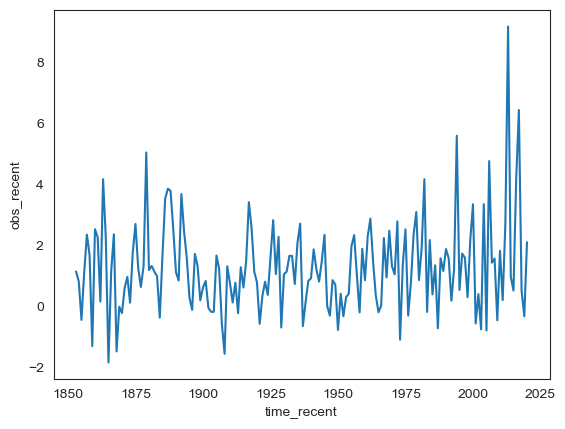

In [54]:
# You see a decline even when data is trained on 1700
#The difference is really just a couple of years
(AR2_noF_1700.trace.log_likelihood.obs_recent.mean(dim=("chain","draw"))-\
 AR2_noF_1000.trace.log_likelihood.obs_recent.mean(dim=("chain","draw"))).plot()

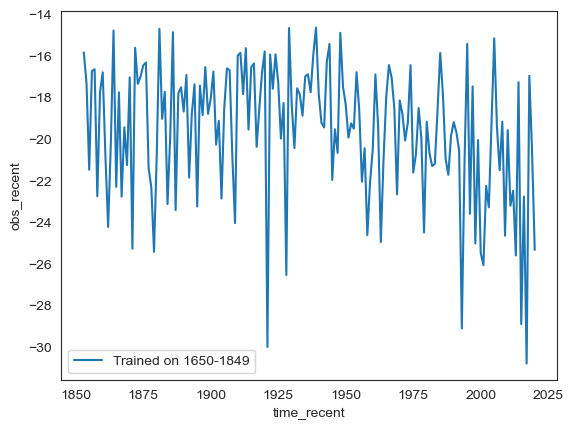

In [55]:
#AR2_noF_1700.trace.log_likelihood.obs_pi.mean(dim=("chain","draw")).plot()

#AR2_noF.trace.log_likelihood.obs_recent.mean(dim=("chain","draw")).plot()

#AR2_noF_1000.trace.log_likelihood.obs_recent.mean(dim=("chain","draw")).plot(label="Trained on 1000-1199")
AR2_noF_1700.trace.log_likelihood.obs_recent.mean(dim=("chain","draw")).plot(label="Trained on 1650-1849")
plt.legend()

<Axes: title={'center': 'β'}>

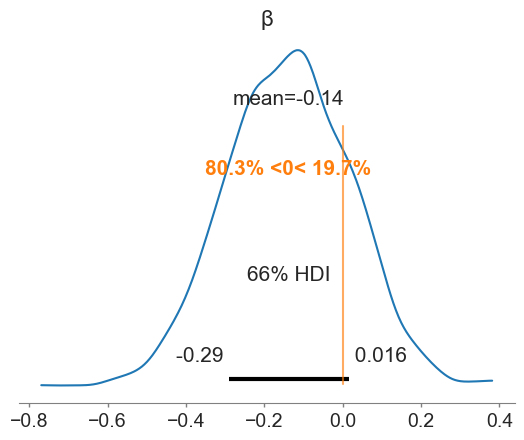

In [56]:
#Which regions have fingerprints with robust sign?
#Enter region here
region="SEA"
az.plot_posterior(global_T_trace.posterior.β.sel(region=region),ref_val=0.,hdi_prob=.66)

# Posterior predictive distributions
np.log(ndata)

In [57]:
class Attributor():
    def __init__(self,PPD=None):
        if PPD is None:
            self.PPD={}
        else:
            self.PPD=PPD
    def add_PPD(self,model,trace,label):
        thinned_data=trace#.sel(draw=slice(None, None, 20))
        self.PPD[label] = pm.sample_posterior_predictive(thinned_data,model=model,var_names=["obs_recent"])
        
    def plot_diff(self,label1,label2,**kwargs):
        diff=self.PPD[label2].posterior_predictive.obs_recent -\
        self.PPD[label1].posterior_predictive.obs_recent
        diff.mean(dim=("chain","draw")).T.plot(cmap=cm.BrBG)
    def time_diff(self,label1,label2,timerange,region=None,**kwargs):
        diff=self.PPD[label2].posterior_predictive.obs_recent -\
        self.PPD[label1].posterior_predictive.obs_recent
        diff_time=diff.sel(time_recent = slice(timerange[0],timerange[1])).mean(dim="time_recent")
        if region is not None:
            az.plot_posterior(diff_time.sel(region=region),ref_val=0,hdi_prob=.66,**kwargs)
        else:
            az.plot_posterior(diff_time,ref_val=0,hdi_prob=.66,**kwargs)
    
        
        

In [58]:
ATT = Attributor()
ATT.add_PPD(global_T_model,global_T_trace,"global_T")
ATT.add_PPD(AR2_noF.model,AR2_noF.trace,"no forcing")

Sampling: [obs_recent]


Sampling: [obs_recent]


In [3]:
diff21=diff.sel(time_recent=slice(2000,2020)).mean(dim=("chain","draw","time_recent"))
#diff.sortby(diff21)

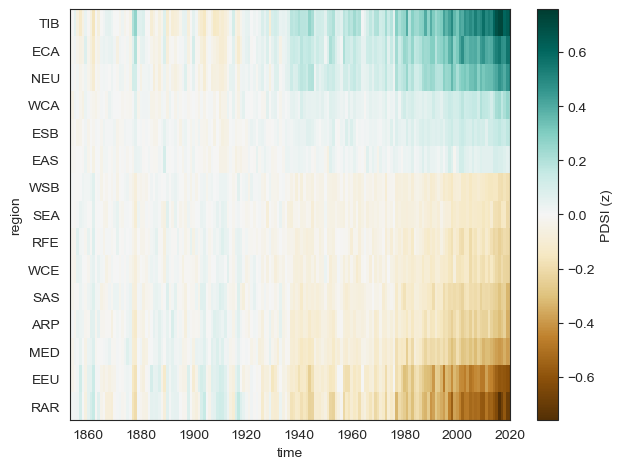

In [87]:
label1="no forcing"
label2 = "global_T"
diff=ATT.PPD[label2].posterior_predictive.obs_recent -\
        ATT.PPD[label1].posterior_predictive.obs_recent
diff=diff.rename("PDSI (z)")

diff21=diff.sel(time_recent=slice(2000,2020)).mean(dim=("chain","draw","time_recent"))
diff=diff.sortby(diff21)
diff.mean(dim=("chain","draw")).T.plot(cmap=cm.BrBG)
ax=plt.gca()
ax.set_xlabel("time")
ax.set_ylim(-.5,14.5)
plt.tight_layout()
plt.savefig("../Writeup/FIGS/GlobalTHovmueller.png")

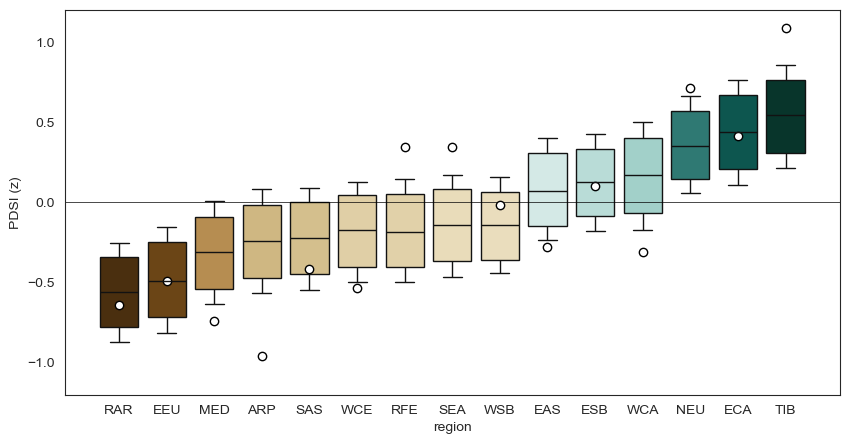

In [85]:
plt.figure(figsize=(10,5))
twentyfirst=diff.sel(time_recent=slice(2000,2020)).mean(dim="time_recent").stack(samples=("chain","draw"))
posteriormean=twentyfirst.mean(dim="samples")
M=np.max(posteriormean)-np.min(posteriormean)
themin=np.min(posteriormean)
colors={}

for reg in posteriormean.region.values:
    i=float(posteriormean.sel(region=reg).values)
    colors[reg]=cm.BrBG((i-themin)/M)
 
#sns.boxplot(twentyfirst.T,fliersize=0,whis=(17,83))
sns.boxplot(twentyfirst.T.to_pandas(),palette=colors,fliersize=0,whis=(17,83))
plt.axhline(0,c="k",lw=.5)
plt.ylabel("PDSI (z)")
plt.plot(recent.sortby(diff21).sel(time=slice(2000,2020)).mean(dim="time").values,"o",color="white",markeredgecolor="k")
#plt.savefig("../Writeup/FIGS/violinplot.png")
#tmp=plt.xticks(np.arange(15),coords["region"],rotation=90)
plt.ylim(-1.2,1.2)
plt.savefig("../Writeup/FIGS/Attributed.png")

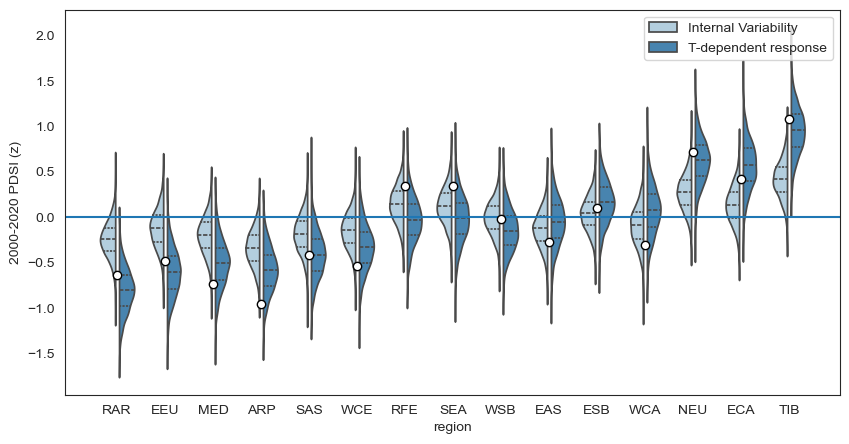

In [86]:
fig=plt.figure(figsize=(10,5))
withforcing=ATT.PPD["global_T"].\
posterior_predictive.obs_recent.stack(samples=("chain","draw")).sel(time_recent=slice(2000,2020)).mean(dim="time_recent")

noforcing=ATT.PPD["no forcing"].\
posterior_predictive.obs_recent.stack(samples=("chain","draw")).sel(time_recent=slice(2000,2020)).mean(dim="time_recent")


#withforcing.expand_dims(coords={"model":"T-dependent response"})
withforcing["model"]="T-dependent response"
#noforcing.expand_dims(coords={"model":"Internal Variability"})
noforcing["model"]="Internal Variability"
both=xr.concat([noforcing,withforcing],dim="model").sortby(diff21)
sns.violinplot(both.to_dataframe(),x="region", y="obs_recent",hue="model",split=True,inner="quart",palette="Blues",\
              gap=.2)
plt.axhline(0)
#plt.plot(recent.sel(time=slice(2000,2020)).mean(dim="time").values,"o",color="darkgoldenrod",label="Observed")
plt.plot(recent.sortby(diff21).sel(time=slice(2000,2020)).mean(dim="time").values,"o",color="white",markeredgecolor="k")
plt.legend()
plt.ylabel("2000-2020 PDSI (z)")
plt.savefig("../Writeup/FIGS/SplitViolin.png")